# Part 9 — Your own data, your 7 strategies, and the iteration loop

Everything so far ran on a simulator with 7 stand-in strategies. This part shows how to plug in
**your** market data and **your** `strategy_1 … strategy_7`, and how to improve an agent
*without fooling yourself*.

1. The two input files you need, and their exact format
2. Loading and validating them (with a data-quality checklist)
3. Real-data pitfalls specific to options
4. **The iteration loop**: hypothesis → one change → fixed evaluation → log → decide
5. One final, one-time test
6. Generalisation tricks (domain randomisation) and deployment and monitoring

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, time, json
import optrl
from optrl import metrics as M
from optrl.data import build_features, load_market_csv, load_pnl_csv, validate_inputs, align, FEATURES
M.set_style()
os.makedirs("data", exist_ok=True)

---
## 9.1 The two input files

**File 1: daily market data** (`data/market_daily.csv`). One row per trading day:

| date | close | vix | vix3m |
|---|---|---|---|
| 2024-10-21 | 5853.98 | 18.37 | 19.92 |

Plus an optional earnings calendar (`data/earnings_dates.csv`, one column `date`) if your
underlying has earnings. For an index, skip it. Sources: your broker or data vendor, or public
sources such as Yahoo Finance (`^GSPC`/`SPY`, `^VIX`, `^VIX3M`) or the CBOE website.

**File 2: your strategies' P&L table** (`data/strategy_pnl.csv`). One row per **decision
date**, one column per strategy:

| date | strategy_1 | strategy_2 | … | strategy_7 |
|---|---|---|---|---|
| 2024-10-21 | 117.0 | 114.0 | … | −1088.0 |

Each cell answers: *"If I had opened strategy k at this date's close and managed it by my
normal rules until exit, what would the P&L have been, net of costs, per fixed unit of risk?"*
That's exactly what your backtester already produces, **for all 7 strategies on every
decision date**, not only the ones you traded. Those counterfactuals are what made the
full-information selector so strong in Part 3.

**Critical conventions**
* **Same risk unit for every strategy** (e.g. sized to \$1,000 max loss). Otherwise the agent
  just learns "pick the biggest position".
* **Net of realistic costs**: commissions plus slippage vs mid, on entry *and* exit.
* **Dated at the decision time**, not the exit date. A trade opened 2024-10-21 and closed
  2024-11-15 belongs on the 2024-10-21 row.

Below we write example files from the simulator, with the columns renamed to
`strategy_1..strategy_7`, so this notebook runs end to end. **Replace them with your own files**
and rerun everything below unchanged.

In [2]:
sim = optrl.load_default_market()
sim.df[["close", "vix", "vix3m"]].rename_axis("date").to_csv("data/market_daily.csv")
pd.Series(sim.df.index[sim.df.is_earnings], name="date").to_csv("data/earnings_dates.csv", index=False)
names = {n: f"strategy_{i + 1}" for i, n in enumerate(optrl.STRATEGY_NAMES)}
optrl.weekly_pnl_table(sim).drop(columns="no_trade").rename(columns=names).round(2).to_csv("data/strategy_pnl.csv")
print("wrote example files:", os.listdir("data"))
print("mapping used for the example:", names)

wrote example files: ['strategy_pnl.csv', 'earnings_dates.csv', 'market_daily.csv']
mapping used for the example: {'short_straddle': 'strategy_1', 'iron_condor': 'strategy_2', 'bull_put_spread': 'strategy_3', 'bear_call_spread': 'strategy_4', 'long_straddle': 'strategy_5', 'bull_call_spread': 'strategy_6', 'bear_put_spread': 'strategy_7'}


### (Optional) downloading real index data
If you have internet access and `pip install yfinance`, this gets you real SPX/VIX/VIX3M data.
You still need **your own strategy P&L table** from your backtester.

```python
import yfinance as yf
px = yf.download(["^GSPC", "^VIX", "^VIX3M"], start="2008-01-01")["Close"].dropna()
px.columns = ["close", "vix", "vix3m"]          # check the column order yfinance returns!
px.rename_axis("date").to_csv("data/market_daily.csv")
```

---
## 9.2 Load, build features, validate

In [3]:
mkt = load_market_csv("data/market_daily.csv")
earn = pd.read_csv("data/earnings_dates.csv", parse_dates=["date"])["date"]
feats = build_features(mkt.close, mkt.vix, mkt.vix3m, earnings_dates=earn)
pnl = load_pnl_csv("data/strategy_pnl.csv")           # adds a 'no_trade' column of zeros

for w in validate_inputs(feats, pnl) or ["no issues found ✓"]:
    print("•", w)
X, R = align(feats, pnl)
print(f"\n{len(X)} usable decision dates, {R.shape[1]} actions: {list(R.columns)}")

• features have NaNs (warm-up?): {'iv_rank': 0.012, 'rv_iv_spread': 0.004, 'ret_5d': 0.001}

995 usable decision dates, 8 actions: ['no_trade', 'strategy_1', 'strategy_2', 'strategy_3', 'strategy_4', 'strategy_5', 'strategy_6', 'strategy_7']


`validate_inputs` flags NaN features. These are the warm-up rows, where the 252-day IV-rank
window and the 20-day realised-vol window aren't full yet, and `align` drops them. That's
expected here. In *your* data, a NaN in the middle of history would be a real problem (a missing
VIX print, a holiday mismatch). Every warning is a question to answer, not something to silence.

### 🛠 Exercise 9.2: break the data on purpose
Validation only helps if it catches real mistakes. Create three broken copies of the P&L
table and confirm `validate_inputs` flags each one: (a) shuffle the row order, (b) set 5
random cells to NaN, (c) scale strategy_3 by 10× (a sizing error).

In [4]:
# TODO

**Solution**

In [5]:
rng = np.random.default_rng(0)
broken = {"shuffled": pnl.sample(frac=1, random_state=0),
          "NaNs": pnl.mask(pd.DataFrame(rng.random(pnl.shape) < 5 / pnl.size, index=pnl.index, columns=pnl.columns)),
          "strategy_3 ×10": pnl.assign(strategy_3=pnl.strategy_3 * 10)}
for k, b in broken.items():
    print(f"{k:15s} →", validate_inputs(feats, b))

shuffled        → ['P&L dates are not sorted', "features have NaNs (warm-up?): {'iv_rank': 0.012, 'rv_iv_spread': 0.004, 'ret_5d': 0.001}", 'gap of 6776 days between decision dates']
NaNs            → ["features have NaNs (warm-up?): {'iv_rank': 0.012, 'rv_iv_spread': 0.004, 'ret_5d': 0.001}", 'P&L table has NaNs: decide explicitly (0 = not tradable?) rather than silently dropping']
strategy_3 ×10  → ["features have NaNs (warm-up?): {'iv_rank': 0.012, 'rv_iv_spread': 0.004, 'ret_5d': 0.001}", "losses > 3x risk unit (sizing? undefined risk?): {'strategy_3': -10229.0}"]


---
## 9.3 Real-data pitfalls specific to options (read before trusting any backtest)

| Pitfall | What goes wrong | Fix |
|---|---|---|
| **Close-time mismatch** | Equity close 4:00pm, options and VIX settle 4:15pm. A feature "at the close" may include information from after your fill | Take features from a snapshot *before* your decision time |
| **Fills at mid** | Backtest fills at mid, but real fills are worse, especially on 4-leg condors | Model slippage per leg (we used 3% of price plus commissions), and stress it (Part 8.7) |
| **VIX as a proxy for your IV** | VIX is 30-day SPX IV. Your 45-DTE single-stock condor has its own IV and skew | Use actual option quotes or the IV surface for your underlying where you can |
| **Early assignment and dividends** | American options on single stocks, short calls around ex-dividend dates | Include them in your backtester's P&L |
| **Earnings date revisions** | "Known" earnings dates are sometimes only confirmed late | Use the date *as known at the decision time* |
| **Survivorship** | Testing only on today's index members or today's liquid names | Point-in-time universes |
| **Regime coverage** | 2010–2019 has little "vol shock" data | Check the regime mix (Part 0's plot). Consider simulated stress worlds (9.6) |
| **Overlapping trades** | 45-DTE trades opened weekly overlap, so weekly P&L rows aren't independent | Use block bootstrap (Part 8.4), and model positions in an MDP env (Part 6) |

---
## 9.4 The iteration loop

```
 ┌─► 1. HYPOTHESIS  "switch costs are eating the edge; require a margin before switching"
 │   2. ONE CHANGE    add a switch threshold (nothing else changes)
 │   3. EVALUATE      the SAME protocol every time: walk-forward on the DEVELOPMENT years only
 │   4. LOG           config + metrics + date + note → experiments.csv
 └── 5. DECIDE        keep / revert / new hypothesis
                      …and only at the very end: ONE run on the untouched TEST years
```

**Analogy.** A lab notebook. A scientist who changes five things at once and only records the
successful run has learned nothing, and can't reproduce it.

### Set up the protocol once

In [6]:
dev_end = X.index[int(len(X) * 0.7)]                  # development: first 70% | test: last 30% (locked away)
Xd, Rd = X[X.index < dev_end], R[R.index < dev_end]
Xtest, Rtest = X[X.index >= dev_end], R[R.index >= dev_end]
SWITCH_COST = 25.0                                    # $ penalty whenever the chosen strategy changes
print(f"development: {Xd.index[0].date()} → {Xd.index[-1].date()} ({len(Xd)} weeks) | test (locked): {len(Xtest)} weeks")

def realized(choices, Rm, switch_cost=SWITCH_COST):
    """Weekly P&L of a sequence of choices, charging a cost whenever the strategy changes."""
    c = np.asarray(choices); pnl_ = Rm.values[np.arange(len(c)), c]
    switched = np.r_[False, c[1:] != c[:-1]] & (c != 0)
    return pnl_ - switch_cost * switched

def walk_forward_dev(select_fn, config, first_fold_frac=0.4, n_folds=6):
    """Yearly-ish folds inside the DEVELOPMENT period only. select_fn(Xtr, Rtr, Xte, config) -> choices."""
    n = len(Xd); edges = np.linspace(int(n * first_fold_frac), n, n_folds + 1).astype(int)
    out = []
    for a, b in zip(edges[:-1], edges[1:]):
        ch = select_fn(Xd.iloc[:a], Rd.iloc[:a], Xd.iloc[a:b], config)
        out.append(pd.Series(realized(ch, Rd.iloc[a:b]), index=Xd.index[a:b]))
    return pd.concat(out)

LOG = []
def log_experiment(name, config, pnl_series, note=""):
    s = M.summarize(pnl_series.values)
    LOG.append({"exp": name, "config": json.dumps(config), "mean $/wk": s.mean_per_period, "sharpe": s.sharpe,
                "max_dd": s.max_drawdown, "cvar_5%": s["cvar_5%"], "note": note})
    return s

development: 2006-03-27 → 2019-07-22 (696 weeks) | test (locked): 299 weeks


### The selectors we'll iterate on
All share one function. The config decides the variant. (Swapping in the PPO or Q-learning
agents from earlier parts works the same way. They're just slower to evaluate.)

In [7]:
def ridge_select(Xtr, Rtr, Xte, cfg):
    cols = cfg.get("features", FEATURES)
    mu, sd = Xtr[cols].mean(), Xtr[cols].std()
    def Z(Xm):
        z = ((Xm[cols] - mu) / sd).clip(-5, 5)
        if cfg.get("earn_flag"):
            z["earn"] = Xm.days_to_earnings.between(1, 5).astype(float)
        return np.c_[np.ones(len(z)), z.values]
    y = Rtr.values / 1000
    if cfg.get("risk_lambda", 0) > 0:                    # learn risk-adjusted value instead of raw P&L
        y = y - cfg["risk_lambda"] * y ** 2
    Ztr = Z(Xtr)
    W = np.linalg.solve(Ztr.T @ Ztr + cfg.get("lam", 1.0) * np.eye(Ztr.shape[1]), Ztr.T @ y)
    pred = Z(Xte) @ W
    thr = cfg.get("switch_threshold", 0.0) / 1000        # hysteresis: only switch for a big enough gain
    choices, cur = [], 0
    for p in pred:
        best = int(np.argmax(p))
        if best != cur and p[best] - p[cur] < thr:
            best = cur
        choices.append(best); cur = best
    return np.array(choices)

def best_single_select(Xtr, Rtr, Xte, cfg):
    return np.full(len(Xte), int(Rtr.mean().values.argmax()))

### Run the experiments, one change at a time

In [8]:
experiments = [
    ("E0 baseline: best single", best_single_select, {}, "what a non-RL researcher would deploy"),
    ("E1 ridge, all features", ridge_select, {"lam": 1.0}, "Part 3 selector"),
    ("E2 + stronger ridge", ridge_select, {"lam": 30.0}, "H: coefficients too noisy"),
    ("E3 drop ret_5d", ridge_select, {"lam": 1.0, "features": [f for f in FEATURES if f != "ret_5d"]}, "H: ret_5d is noise (Part 3 ablation)"),
    ("E4 + earnings flag", ridge_select, {"lam": 1.0, "earn_flag": True}, "H: sit out earnings weeks"),
    ("E5 switch threshold $50", ridge_select, {"lam": 1.0, "switch_threshold": 50}, "H: switching costs eat the edge"),
    ("E6 risk-aware target λ=0.5", ridge_select, {"lam": 1.0, "risk_lambda": 0.5}, "H: avoid fat-tailed strategies"),
    ("E7 risk-aware + threshold", ridge_select, {"lam": 1.0, "risk_lambda": 0.5, "switch_threshold": 50}, "combine E5 + E6"),
]
dev_curves = {}
for name, fn, cfg, note in experiments:
    dev_curves[name] = walk_forward_dev(fn, cfg)
    log_experiment(name, cfg, dev_curves[name], note)

log = pd.DataFrame(LOG)
log.to_csv("data/experiments.csv", index=False)
log.drop(columns="config").round(2)

,exp,mean $/wk,sharpe,max_dd,cvar_5%,note
0,E0 baseline: best single,45.95,1.03,6305.20,-1013.98,what a non-RL researcher would deploy
1,"E1 ridge, all features",116.66,1.39,3018.05,-1094.71,Part 3 selector
2,E2 + stronger ridge,117.62,1.46,3596.18,-1093.73,H: coefficients too noisy
3,E3 drop ret_5d,110.77,1.37,2824.60,-1098.01,H: ret_5d is noise (Part 3 ablation)
4,E4 + earnings flag,110.12,1.18,3231.06,-1104.70,H: sit out earnings weeks
5,E5 switch threshold $50,142.39,1.79,2708.66,-1075.86,H: switching costs eat the edge
6,E6 risk-aware target λ=0.5,74.04,2.42,1883.00,-711.57,H: avoid fat-tailed strategies
7,E7 risk-aware + threshold,86.77,2.81,2047.26,-713.37,combine E5 + E6


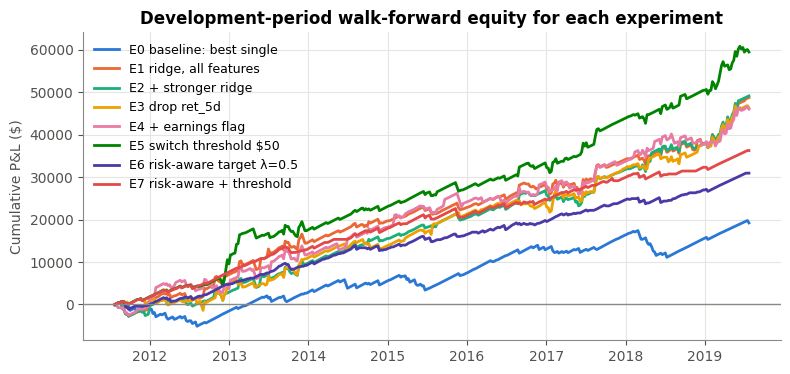

In [9]:
M.plot_equity({k: v for k, v in dev_curves.items()}, title="Development-period walk-forward equity for each experiment")
plt.show()

**Deciding, like a researcher.**
* Compare each experiment with the one it modified, not just with the leader.
* Prefer the variant whose improvement makes **economic sense** and shows up on more than one
  metric (e.g. higher Sharpe *and* smaller drawdown).
* Remember best-of-N (Part 8.5): we ran 8 experiments, so the top one is flattered. Small
  differences (a few \$/week, Sharpe ±0.1) are noise.

Pick the configuration by **development Sharpe**, then evaluate it **once** on the locked test years.

In [10]:
chosen = log.sort_values("sharpe", ascending=False).iloc[0]
print("chosen by development Sharpe:", chosen.exp, chosen.config)

chosen by development Sharpe: E7 risk-aware + threshold {"lam": 1.0, "risk_lambda": 0.5, "switch_threshold": 50}


---
## 9.5 The one-time final test
Train on **all** development data with the chosen config, then run through the test years once.
Whatever comes out is your honest estimate. **Don't go back and tune after seeing it.** If you
do, the test set becomes a development set, and you need new unseen data.

                                   total_pnl  mean_per_period  sharpe  max_drawdown  cvar_5%  win_rate
chosen: E7 risk-aware + threshold   22061.58            73.78    1.98       2332.61  -944.34      0.88
best single                         14052.86            47.00    1.10       4165.01  -931.34      0.81


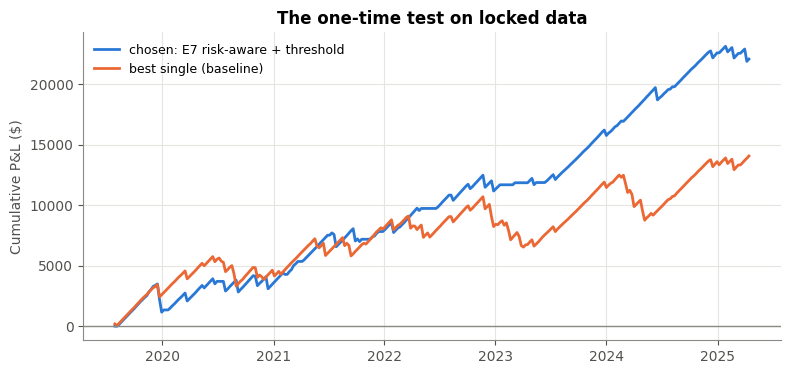

In [11]:
cfg = json.loads(chosen.config)
fn = dict((e[0], e[1]) for e in experiments)[chosen.exp]
final = pd.Series(realized(fn(Xd, Rd, Xtest, cfg), Rtest), index=Xtest.index)
base = pd.Series(realized(best_single_select(Xd, Rd, Xtest, {}), Rtest), index=Xtest.index)
print(pd.DataFrame({f"chosen: {chosen.exp}": M.summarize(final.values), "best single": M.summarize(base.values)}).T.round(2).to_string())
M.plot_equity({f"chosen: {chosen.exp}": final, "best single (baseline)": base}, title="The one-time test on locked data")
plt.show()

---
## 9.6 Generalisation: training on many simulated worlds (domain randomisation)

Your history contains *one* sequence of regimes. An RL agent trained only on it may learn "the
shape of 2008–2019" instead of "how to select strategies". **Domain randomisation** trains on
many *plausible* worlds, the real history plus simulated histories with perturbed regime
parameters (drift, vol, vol premium), so the agent must learn rules that work across them.

It's standard in robotics (train in many randomised simulators, deploy in reality). In
trading its value depends on how realistic your simulator is. **Measure it; don't assume it.**

### 🛠 Exercise 9.6
Train the tabular Q-learner (Part 5) on (a) the training history only and (b) the training
history plus 6 perturbed worlds (±20% on each regime parameter). Evaluate both on the
simulator's test period for **3 training seeds**.

*Expected:* **mixed, and highly seed-dependent.** In some seeds the randomised agent is much
more robust, in others worse. The honest conclusion from 3 seeds is "unproven". You'd need many
more seeds, and realistic world generators, before adopting it. Practising this conclusion is
the point of the exercise.

In [12]:
# TODO

**Solution**

In [13]:
F = optrl.MarketData.FEATURES
tr_hist, te_hist = sim.split(0.7)
stats = (tr_hist.df[F].mean().values, tr_hist.df[F].std().values)

def perturbed_world(seed, scale=0.2):
    rng = np.random.default_rng(seed)
    rp = {k: {p: (v * (1 + scale * rng.uniform(-1, 1)) if p != "ts" else v) for p, v in d.items()}
          for k, d in optrl.REGIME_PARAMS.items()}
    return optrl.simulate_market(n_days=252 * 14, seed=1000 + seed, regime_params=rp)

def train_q_multi(markets, episodes, seed=0, gamma=0.9, alpha=0.05):
    envs = [optrl.DiscretizeObs(optrl.OptionsSelectionEnv(m_, seed=seed + i)) for i, m_ in enumerate(markets)]
    Q = np.zeros((216, 8)); rng = np.random.default_rng(seed)
    for ep in range(episodes):
        env = envs[rng.integers(len(envs))]; eps = max(0.05, 1 - ep / (0.7 * episodes))
        s, _ = env.reset(); done = False
        while not done:
            a = int(rng.integers(8)) if rng.random() < eps else int(Q[s].argmax())
            s2, r, te, tr, _ = env.step(a); done = te or tr
            Q[s, a] += alpha * (r + (0 if te else gamma * Q[s2].max()) - Q[s, a]); s = s2
    return Q

bk = optrl.DiscretizeObs.market_buckets(te_hist.df)
qpol = lambda Q: (lambda o, e: int(Q[bk[e.i] * 8 + int(np.argmax(o[len(F):len(F) + 8]))].argmax()))
worlds = [perturbed_world(s) for s in range(6)]
rows = {}
for seed in [0, 1, 2]:
    for label, mkts, eps_ in [("history only", [tr_hist], 2000), ("history + 6 worlds", [tr_hist] + worlds, 4000)]:
        r = M.full_period_rollout(optrl.OptionsSelectionEnv, te_hist, qpol(train_q_multi(mkts, eps_, seed)), obs_stats=stats)
        rows[(label, seed)] = {"test $/wk": r.pnl.mean(), "sharpe": M.sharpe(r.pnl)}
res = pd.DataFrame(rows).T
print(res.round(2).to_string()); print("\nmean over seeds:\n", res.groupby(level=0).mean().round(2).to_string())

                      test $/wk  sharpe
history only       0      56.16    0.86
history + 6 worlds 0      12.34    0.25
history only       1      30.59    0.49
history + 6 worlds 1       9.72    0.27
history only       2      12.42    0.21
history + 6 worlds 2      39.99    1.31

mean over seeds:
                     test $/wk  sharpe
history + 6 worlds      20.68    0.61
history only            33.06    0.52


---
## 9.7 From backtest to live: deployment and monitoring

**Before real money**
- [ ] Paper-trade the agent for a set period (e.g. 3–6 months) using live data and **your real
      fills**. Compare paper P&L with what the backtest would have predicted for the same weeks.
- [ ] Start with a **fraction** of the intended risk budget.
- [ ] Write down a **kill switch** in advance, e.g. "drawdown > 2× the worst walk-forward
      drawdown" or "3 months below the best-single baseline" → revert to the baseline strategy.
- [ ] Keep a human in the loop: the agent *proposes*, you *approve*, at least at first.

**While live, monitor three kinds of drift**

In [14]:
def drift_report(X_train, X_recent, actions_train, actions_recent, z_alarm=2.5):
    """Feature drift (z-score of recent means vs training distribution) and action-mix drift."""
    z = ((X_recent.mean() - X_train.mean()) / (X_train.std() / np.sqrt(len(X_recent)))).round(2)
    feat = pd.DataFrame({"recent mean": X_recent.mean().round(2), "train mean": X_train.mean().round(2), "z": z,
                         "ALARM": np.where(z.abs() > z_alarm, "⚠", "")})
    mix = pd.DataFrame({"train mix": pd.Series(actions_train).value_counts(normalize=True),
                        "recent mix": pd.Series(actions_recent).value_counts(normalize=True)}).fillna(0).round(2)
    return feat, mix

ch_dev = ridge_select(Xd, Rd, Xd, cfg); ch_recent = ridge_select(Xd, Rd, Xtest.iloc[-26:], cfg)
names_ = np.array(R.columns)
feat_drift, mix_drift = drift_report(Xd, Xtest.iloc[-26:], names_[ch_dev], names_[ch_recent])
print("1) FEATURE DRIFT: last 26 weeks vs development period"); print(feat_drift.to_string())
print("\n2) ACTION-MIX DRIFT"); print(mix_drift.to_string())

1) FEATURE DRIFT: last 26 weeks vs development period
                  recent mean  train mean     z ALARM
vix                     16.34       18.08 -1.73      
iv_rank                 22.80       32.28 -1.91      
term_structure           0.91        0.93 -1.97      
ema_trend                0.19       -0.06  0.87      
rv_iv_spread            -4.25       -1.45 -2.02      
days_to_earnings        38.08       30.92  2.00      
ret_5d                   0.37        0.03  0.61      

2) ACTION-MIX DRIFT
            train mix  recent mix
no_trade         0.13        0.04
strategy_1       0.11        0.00
strategy_2       0.00        0.00
strategy_3       0.52        0.85
strategy_4       0.24        0.12


3. **Performance drift**: rolling realised P&L vs the backtest's expected P&L for the same
   states. For value-based agents, track *predicted value vs realised return* (Part 7a's alarm).

A feature alarm isn't automatically bad (markets change), but it means the agent is operating
**outside the conditions it learned from**, and its confidence should drop accordingly.

## Recap
* You need two files: **daily market data** and **your 7 strategies' P&L per decision date**
  (the counterfactual backtest table). Same risk unit, net of costs, dated at decision time.
* **Validate** the data aggressively. Know the options-specific pitfalls.
* **Iterate** with one change at a time, a fixed walk-forward protocol on development data, and
  a written experiment log. Test **once**.
* Treat generalisation tricks as hypotheses to measure, not magic.
* Deploy gradually, with a kill switch and drift monitoring.

**Next → Part 10:** the capstone brief. Build the whole thing yourself.